<a href="https://colab.research.google.com/github/nikaicheng66-cloud/DATA-Mining/blob/main/Dataming_Project_1_Kaicheng_Ni.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

A

In [ ]:
pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo
import pandas as pd

# fetch dataset
concrete_compressive_strength = fetch_ucirepo(id=165)

# data (as pandas dataframes)
X = concrete_compressive_strength.data.features
y = concrete_compressive_strength.data.targets

# metadata
print(concrete_compressive_strength.metadata)

# variable information
print(concrete_compressive_strength.variables)

{'uci_id': 165, 'name': 'Concrete Compressive Strength', 'repository_url': 'https://archive.ics.uci.edu/dataset/165/concrete+compressive+strength', 'data_url': 'https://archive.ics.uci.edu/static/public/165/data.csv', 'abstract': 'Concrete is the most important material in civil engineering. The concrete compressive strength is a highly nonlinear function of age and ingredients. ', 'area': 'Physics and Chemistry', 'tasks': ['Regression'], 'characteristics': ['Multivariate'], 'num_instances': 1030, 'num_features': 8, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Concrete compressive strength'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1998, 'last_updated': 'Sun Feb 11 2024', 'dataset_doi': '10.24432/C5PK67', 'creators': ['I-Cheng Yeh'], 'intro_paper': {'ID': 383, 'type': 'NATIVE', 'title': 'Modeling of strength of high-performance concrete using artificial neural networks', 'authors': 'I. Yeh', 'venue': 'C

In [ ]:
display(X.describe())
y.info()
print()
X.info()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 1 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Concrete compressive strength  1030 non-null   float64
dtypes: float64(1)
memory usage: 8.2 KB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Cement              1030 non-null   float64
 1   Blast Furnace Slag  1030 non-null   float64
 2   Fly Ash             1030 non-null   float64
 3   Water               1030 non-null   float64
 4   Superplasticizer    1030 non-null   float64
 5   Coarse Aggregate    1030 non-null   float64
 6   Fine Aggregate      1030 non-null   float64
 7   Age                 1030 non-null   int64  
dtypes: float64(7), int64(1)
memory usage: 64.5 KB


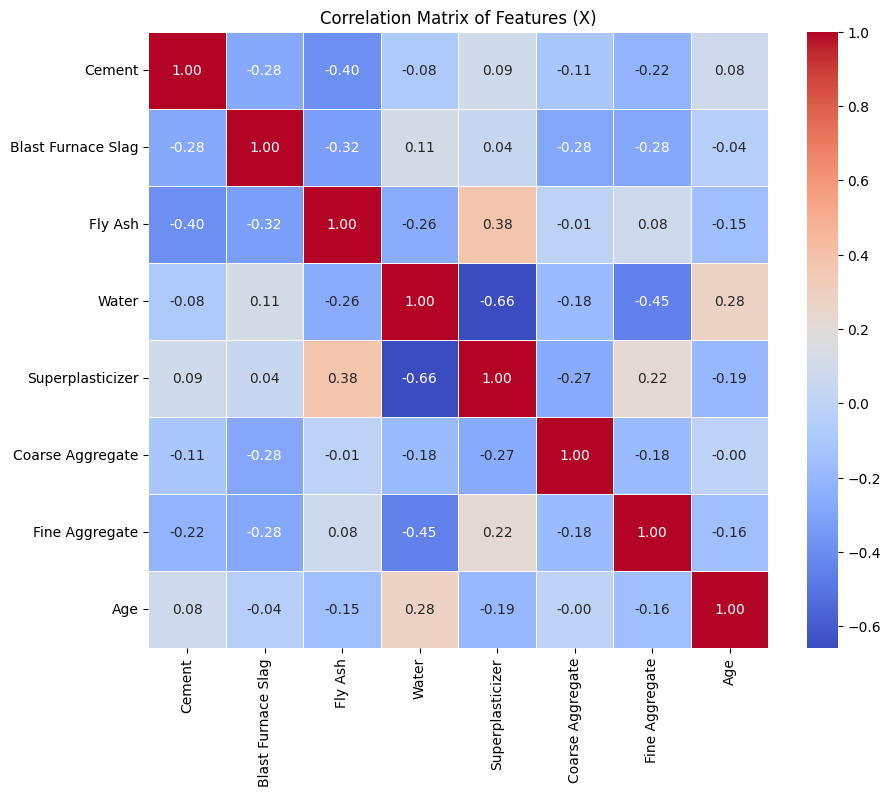

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix for X
correlation_matrix = X.corr()

# Plotting the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Features (X)')
plt.show()

In [ ]:
test_start_index = 501
test_end_index = 630

# Create the test sets
X_test = X.iloc[test_start_index : test_end_index + 1]
y_test = y.iloc[test_start_index : test_end_index + 1]

# Create the training sets by excluding the test set indices
X_train = pd.concat([X.iloc[:test_start_index], X.iloc[test_end_index + 1:]])
y_train = pd.concat([y.iloc[:test_start_index], y.iloc[test_end_index + 1:]])

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit on training set only
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create DataFrames for scaled data
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("Original X_train head:")
display(X_train.head())

print("\nScaled X_train head (X_train_scaled_df):")
display(X_train_scaled_df.head())

print("\nScaled X_test head (X_test_scaled_df):")
display(X_test_scaled_df.head())

Original X_train head:


,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360



Scaled X_train head (X_train_scaled_df):


,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
0,2.466329,-0.906339,-0.895412,-0.841332,-0.731123,0.858331,-1.174739,-0.294437
1,2.466329,-0.906339,-0.895412,-0.841332,-0.731123,1.051753,-1.174739,-0.294437
2,0.511805,0.789954,-0.895412,2.121720,-1.149514,-0.534312,-2.176289,3.654355
3,0.511805,0.789954,-0.895412,2.121720,-1.149514,-0.534312,-2.176289,5.204501
4,-0.749452,0.669726,-0.895412,0.505510,-1.149514,0.064009,0.651257,5.122914



Scaled X_test head (X_test_scaled_df):


,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
0,2.004779,-0.59684,1.019473,1.313615,-0.496825,-1.179054,-0.893817,-0.702370
1,2.004779,-0.59684,1.019473,1.313615,-0.496825,-1.179054,-0.893817,-0.637101
2,2.004779,-0.59684,1.019473,1.313615,-0.496825,-1.179054,-0.893817,0.162448
3,2.004779,-0.59684,1.019473,0.909562,-0.496825,-1.952744,-0.893817,-0.702370
4,2.004779,-0.59684,1.019473,0.909562,-0.496825,-1.952744,-0.893817,-0.637101


B.1.1

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
cl = X_train.columns
results = {}

for feature_name in cl:
  x_data_train = X_train_scaled_df[[feature_name]].values
  y_data_train = y_train.values
  w = 0.01
  b = 0.02
  alpha = 0.00001
  t = 100000
  n = len(y_data_train)

  for i in range(t):
    y_pred_train_iter = w * x_data_train + b # Prediction during iteration
    error = y_pred_train_iter - y_data_train

    w_gradient = (2/n) * (error * x_data_train).sum()
    b_gradient = (2/n) * error.sum()

    w = w - alpha * w_gradient
    b = b - alpha * b_gradient

  results[feature_name] = {'w': w, 'b': b}
  y_pred_train_final = w * x_data_train + b
  mse_train = mean_squared_error(y_data_train, y_pred_train_final)
  r2_train = r2_score(y_data_train, y_pred_train_final)
  x_data_test = X_test_scaled_df[[feature_name]].values
  y_pred_test = w * x_data_test + b
  mse_test = mean_squared_error(y_test, y_pred_test)
  r2_test = r2_score(y_test, y_pred_test)

  print(f"\n--- Metrics for {feature_name} ---")
  print(f"Final w: {w}")
  print(f"Final b: {b}")
  print(f"Mean Squared Error (MSE) - Train: {mse_train:.2f}")
  print(f"R-squared (R2) - Train: {r2_train:.2f}")
  print(f"Mean Squared Error (MSE) - Test: {mse_test:.2f}")
  print(f"R-squared (R2) - Test: {r2_test:.2f}")



--- Metrics for Cement ---
Final w: 7.417003019096737
Final b: 31.97119063236147
Mean Squared Error (MSE) - Train: 229.88
R-squared (R2) - Train: 0.17
Mean Squared Error (MSE) - Test: 183.05
R-squared (R2) - Test: 0.16

--- Metrics for Blast Furnace Slag ---
Final w: 2.2687276659193674
Final b: 31.97119063236147
Mean Squared Error (MSE) - Train: 295.34
R-squared (R2) - Train: -0.07
Mean Squared Error (MSE) - Test: 245.25
R-squared (R2) - Test: -0.13

--- Metrics for Fly Ash ---
Final w: -2.9602435915197334
Final b: 31.97119063236147
Mean Squared Error (MSE) - Train: 290.57
R-squared (R2) - Train: -0.05
Mean Squared Error (MSE) - Test: 291.83
R-squared (R2) - Test: -0.34

--- Metrics for Water ---
Final w: -3.9641579596632255
Final b: 31.971190632361477
Mean Squared Error (MSE) - Train: 281.44
R-squared (R2) - Train: -0.02
Mean Squared Error (MSE) - Test: 210.20
R-squared (R2) - Test: 0.03

--- Metrics for Superplasticizer ---
Final w: 4.563775471570599
Final b: 31.97119063236147
Mean 

B.1.2

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
cl = X_train.columns
results_unscaled = {}

for feature_name in cl:
  x_data_train_unscaled = X_train[[feature_name]].values
  y_data_train = y_train.values

  w = 0.01
  b = 0.02
  alpha = 0.000001
  t = 10000000
  n = len(y_data_train)


  for i in range(t):
    y_pred_train_iter = w * x_data_train_unscaled + b
    error = y_pred_train_iter - y_data_train

    w_gradient = (2/n) * (error * x_data_train_unscaled).sum()
    b_gradient = (2/n) * error.sum()

    w = w - alpha * w_gradient
    b = b - alpha * b_gradient


  results_unscaled[feature_name] = {'w': w, 'b': b}

  y_pred_train_final = w * x_data_train_unscaled + b

  mse_train = mean_squared_error(y_data_train, y_pred_train_final)
  r2_train = r2_score(y_data_train, y_pred_train_final)

  x_data_test_unscaled = X_test[[feature_name]].values
  y_pred_test = w * x_data_test_unscaled + b

  mse_test = mean_squared_error(y_test, y_pred_test)
  r2_test = r2_score(y_test, y_pred_test)

  print(f"\n--- Metrics for {feature_name} (Unscaled Data) ---")
  print(f"Final w: {w}")
  print(f"Final b: {b}")
  print(f"Mean Squared Error (MSE) - Train: {mse_train:.2f}")
  print(f"R-squared (R2) - Train: {r2_train:.2f}")
  print(f"Mean Squared Error (MSE) - Test: {mse_test:.2f}")
  print(f"R-squared (R2) - Test: {r2_test:.2f}")



--- Metrics for Cement (Unscaled Data) ---
Final w: 0.08435700942856267
Final b: 13.362063554617837
Mean Squared Error (MSE) - Train: 203.69
R-squared (R2) - Train: 0.26
Mean Squared Error (MSE) - Test: 265.98
R-squared (R2) - Test: -0.22

--- Metrics for Blast Furnace Slag (Unscaled Data) ---
Final w: 0.03121826178133433
Final b: 34.594763184963995
Mean Squared Error (MSE) - Train: 270.20
R-squared (R2) - Train: 0.02
Mean Squared Error (MSE) - Test: 309.08
R-squared (R2) - Test: -0.42

--- Metrics for Fly Ash (Unscaled Data) ---
Final w: -0.05331831403368557
Final b: 40.038296688933166
Mean Squared Error (MSE) - Train: 265.35
R-squared (R2) - Train: 0.04
Mean Squared Error (MSE) - Test: 382.77
R-squared (R2) - Test: -0.76

--- Metrics for Water (Unscaled Data) ---
Final w: 0.09378060384659152
Final b: 19.199475403729746
Mean Squared Error (MSE) - Train: 301.28
R-squared (R2) - Train: -0.09
Mean Squared Error (MSE) - Test: 309.72
R-squared (R2) - Test: -0.42

--- Metrics for Superplas

In [ ]:
[w_1,w_2,w_3,b] = [1,1,1,1]
[x_1,x_2,x_3] = [3,4,5]
y = 4
alpha = 0.1
y_pred = w_1*x_1 + w_2*x_2 + w_3*x_3 + b
error = y_pred - y
grad_1 = 2*error*x_1
grad_2 = 2*error*x_2
grad_3 = 2*error*x_3
w_1 = w_1 - alpha * grad_1
w_2 = w_2 - alpha * grad_2
w_3 = w_3 - alpha * grad_3
b = b - alpha * error*2

print(w_1)
print(w_2)
print(w_3)
print(b)

-4.4
-6.2
-8.0
-0.8


In [ ]:
[grad_1_total,grad_2_total,grad_3_total,grad_b_total] = [0,0,0,0]
n = 5
alpha = 0.1
[w_1,w_2,w_3,b] = [1,1,1,1]
for [x_1,x_2,x_3,y] in [[3,4,4,3],[4,2,1,2],[10,2,5,8],[3,4,5,4],[11,1,1,5]]:
  alpha = 0.1
  y_pred = w_1*x_1 + w_2*x_2 + w_3*x_3 + b
  error = y_pred - y
  grad_1 = 2*error*x_1
  grad_2 = 2*error*x_2
  grad_3 = 2*error*x_3
  grad_b = 2*error
  grad_1_total = grad_1_total + grad_1
  grad_2_total = grad_2_total + grad_2
  grad_3_total = grad_3_total + grad_3
  grad_b_total = grad_b_total + grad_b
grad_1 = grad_1_total/n
grad_2 = grad_2_total/n
grad_3 = grad_3_total/n
grad_b = grad_b_total/n
w_1 = w_1 - alpha * grad_1
w_2 = w_2 - alpha * grad_2
w_3 = w_3 - alpha * grad_3
b = b - alpha * grad_b

print(w_1)
print(w_2)
print(w_3)
print(b)

-10.08
-3.5200000000000005
-4.84
-0.72


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

[m_1,m_2,m_3,m_4,m_5,m_6,m_7,m_8,b] = [0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1]
[x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8] = [
    X_train_scaled_df[['Cement']].values,
    X_train_scaled_df[['Blast Furnace Slag']].values,
    X_train_scaled_df[['Fly Ash']].values,
    X_train_scaled_df[['Water']].values,
    X_train_scaled_df[['Superplasticizer']].values,
    X_train_scaled_df[['Coarse Aggregate']].values,
    X_train_scaled_df[['Fine Aggregate']].values,
    X_train_scaled_df[['Age']].values
]
alpha = 0.01
n = 10000
for i in range(n):
  y_pred = m_1*x_1 + m_2*x_2 + m_3*x_3 + m_4*x_4 + m_5*x_5 + m_6*x_6 + m_7*x_7 + m_8*x_8 + b
  y_data_train = y_train.values
  error = y_pred - y_data_train
  grad_1 = np.mean(2*error*x_1)
  grad_2 = np.mean(2*error*x_2)
  grad_3 = np.mean(2*error*x_3)
  grad_4 = np.mean(2*error*x_4)
  grad_5 = np.mean(2*error*x_5)
  grad_6 = np.mean(2*error*x_6)
  grad_7 = np.mean(2*error*x_7)
  grad_8 = np.mean(2*error*x_8)
  grad_b = np.mean(2*error)

  m_1 = m_1 - alpha*grad_1
  m_2 = m_2 - alpha*grad_2
  m_3 = m_3 - alpha*grad_3
  m_4 = m_4 - alpha*grad_4
  m_5 = m_5 - alpha*grad_5
  m_6 = m_6 - alpha*grad_6
  m_7 = m_7 - alpha*grad_7
  m_8 = m_8 - alpha*grad_8
  b = b - alpha*grad_b

print("Final parameters:")
print(f"m_1: {m_1}")
print(f"m_2: {m_2}")
print(f"m_3: {m_3}")
print(f"m_4: {m_4}")
print(f"m_5: {m_5}")
print(f"m_6: {m_6}")
print(f"m_7: {m_7}")
print(f"m_8: {m_8}")
print(f"b: {b}")

y_pred_train = m_1*x_1 + m_2*x_2 + m_3*x_3 + m_4*x_4 + m_5*x_5 + m_6*x_6 + m_7*x_7 + m_8*x_8 + b
mse_train = mean_squared_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)

[tx_1, tx_2, tx_3, tx_4, tx_5, tx_6, tx_7, tx_8] = [
    X_test_scaled_df[['Cement']].values,
    X_test_scaled_df[['Blast Furnace Slag']].values,
    X_test_scaled_df[['Fly Ash']].values,
    X_test_scaled_df[['Water']].values,
    X_test_scaled_df[['Superplasticizer']].values,
    X_test_scaled_df[['Coarse Aggregate']].values,
    X_test_scaled_df[['Fine Aggregate']].values,
    X_test_scaled_df[['Age']].values
]
y_pred_test = m_1*tx_1 + m_2*tx_2 + m_3*tx_3 + m_4*tx_4 + m_5*tx_5 + m_6*tx_6 + m_7*tx_7 + m_8*tx_8 + b
mse_test = mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

print(f"Mean Squared Error (MSE) - Train: {mse_train:.2f}")
print(f"R-squared (R2) - Train: {r2_train:.2f}")
print(f"Mean Squared Error (MSE) - Test: {mse_test:.2f}")
print(f"R-squared (R2) - Test: {r2_test:.2f}")

Final parameters:
m_1: 14.074651016653336
m_2: 10.476722885919454
m_3: 6.831227303001915
m_4: -2.990205634021727
m_5: 0.6913161594986456
m_6: 2.1989728596935523
m_7: 2.7639202235056652
m_8: 7.277887265160101
b: 36.97199999999984
Mean Squared Error (MSE) - Train: 104.15
R-squared (R2) - Train: 0.62
Mean Squared Error (MSE) - Test: 141.18
R-squared (R2) - Test: 0.35


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Initialize parameters
[m_1,m_2,m_3,m_4,m_5,m_6,m_7,m_8,b] = [0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1]

# Use UNSCALED training data
[x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8] = [
    X_train[['Cement']].values,
    X_train[['Blast Furnace Slag']].values,
    X_train[['Fly Ash']].values,
    X_train[['Water']].values,
    X_train[['Superplasticizer']].values,
    X_train[['Coarse Aggregate']].values,
    X_train[['Fine Aggregate']].values,
    X_train[['Age']].values
]

# Adjust hyperparameters for unscaled data
alpha = 0.0000001 # Much smaller learning rate needed for unscaled data
n = 1000000 # More iterations might be needed

for i in range(n):
  y_pred = m_1*x_1 + m_2*x_2 + m_3*x_3 + m_4*x_4 + m_5*x_5 + m_6*x_6 + m_7*x_7 + m_8*x_8 + b
  y_data_train = y_train.values
  error = y_pred - y_data_train

  # Calculate gradients
  grad_1 = np.mean(2*error*x_1)
  grad_2 = np.mean(2*error*x_2)
  grad_3 = np.mean(2*error*x_3)
  grad_4 = np.mean(2*error*x_4)
  grad_5 = np.mean(2*error*x_5)
  grad_6 = np.mean(2*error*x_6)
  grad_7 = np.mean(2*error*x_7)
  grad_8 = np.mean(2*error*x_8)
  grad_b = np.mean(2*error)

  # Update parameters
  m_1 = m_1 - alpha*grad_1
  m_2 = m_2 - alpha*grad_2
  m_3 = m_3 - alpha*grad_3
  m_4 = m_4 - alpha*grad_4
  m_5 = m_5 - alpha*grad_5
  m_6 = m_6 - alpha*grad_6
  m_7 = m_7 - alpha*grad_7
  m_8 = m_8 - alpha*grad_8
  b = b - alpha*grad_b

print("Final parameters (Unscaled):")
print(f"m_1: {m_1}")
print(f"m_2: {m_2}")
print(f"m_3: {m_3}")
print(f"m_4: {m_4}")
print(f"m_5: {m_5}")
print(f"m_6: {m_6}")
print(f"m_7: {m_7}")
print(f"m_8: {m_8}")
print(f"b: {b}")

# --- Evaluation ---
# 1. Training Set Evaluation
y_pred_train = m_1*x_1 + m_2*x_2 + m_3*x_3 + m_4*x_4 + m_5*x_5 + m_6*x_6 + m_7*x_7 + m_8*x_8 + b
mse_train = mean_squared_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)

# 2. Test Set Evaluation
# Use UNSCALED test data variables
[tx_1, tx_2, tx_3, tx_4, tx_5, tx_6, tx_7, tx_8] = [
    X_test[['Cement']].values,
    X_test[['Blast Furnace Slag']].values,
    X_test[['Fly Ash']].values,
    X_test[['Water']].values,
    X_test[['Superplasticizer']].values,
    X_test[['Coarse Aggregate']].values,
    X_test[['Fine Aggregate']].values,
    X_test[['Age']].values
]

y_pred_test = m_1*tx_1 + m_2*tx_2 + m_3*tx_3 + m_4*tx_4 + m_5*tx_5 + m_6*tx_6 + m_7*tx_7 + m_8*tx_8 + b
mse_test = mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

print("\n--- Multiple Linear Regression Results (Unscaled Data) ---")
print(f"Mean Squared Error (MSE) - Train: {mse_train:.2f}")
print(f"R-squared (R2) - Train: {r2_train:.2f}")
print(f"Mean Squared Error (MSE) - Test: {mse_test:.2f}")
print(f"R-squared (R2) - Test: {r2_test:.2f}")

Final parameters (Unscaled):
m_1: 0.11802284580861742
m_2: 0.10699450251942376
m_3: 0.08625533809080735
m_4: -0.2041326281398381
m_5: 0.06096730314028895
m_6: 0.011034880585850533
m_7: 0.014538202219602916
m_8: 0.11841941566141755
b: 0.09800451891870816

--- Multiple Linear Regression Results (Unscaled Data) ---
Mean Squared Error (MSE) - Train: 104.54
R-squared (R2) - Train: 0.62
Mean Squared Error (MSE) - Test: 138.11
R-squared (R2) - Test: 0.37


In [ ]:
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, r2_score

# Add a constant (intercept) to the training features for statsmodels
X_train_sm = sm.add_constant(X_train)

# Fit the OLS (Ordinary Least Squares) model on the training data
model = sm.OLS(y_train, X_train_sm)
results = model.fit()

# Print the model summary which includes statistical analysis
print(results.summary())


                                  OLS Regression Results                                 
Dep. Variable:     Concrete compressive strength   R-squared:                       0.624
Model:                                       OLS   Adj. R-squared:                  0.621
Method:                            Least Squares   F-statistic:                     184.9
Date:                           Tue, 24 Feb 2026   Prob (F-statistic):          1.80e-183
Time:                                   22:08:42   Log-Likelihood:                -3367.7
No. Observations:                            900   AIC:                             6753.
Df Residuals:                                891   BIC:                             6797.
Df Model:                                      8                                         
Covariance Type:                       nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
-------------

In [ ]:
# Evaluate the model on the training data
y_pred_train_sm = results.predict(X_train_sm)
mse_train_sm = mean_squared_error(y_train, y_pred_train_sm)
r2_train_sm = r2_score(y_train, y_pred_train_sm)

# Prepare the test data with a constant
X_test_sm = sm.add_constant(X_test)

# Evaluate the model on the test data
y_pred_test_sm = results.predict(X_test_sm)
mse_test_sm = mean_squared_error(y_test, y_pred_test_sm)
r2_test_sm = r2_score(y_test, y_pred_test_sm)

print("\n--- Statsmodels Multivariate Linear Regression Results (Unscaled Data) ---")
print(f"Mean Squared Error (MSE) - Train: {mse_train_sm:.2f}")
print(f"R-squared (R2) - Train: {r2_train_sm:.2f}")
print(f"Mean Squared Error (MSE) - Test: {mse_test_sm:.2f}")
print(f"R-squared (R2) - Test: {r2_test_sm:.2f}")



--- Statsmodels Multivariate Linear Regression Results (Unscaled Data) ---
Mean Squared Error (MSE) - Train: 104.15
R-squared (R2) - Train: 0.62
Mean Squared Error (MSE) - Test: 141.26
R-squared (R2) - Test: 0.35


In [ ]:
# Add a constant to the scaled training data
X_train_scaled_sm = sm.add_constant(X_train_scaled_df)

# Fit the OLS model on the scaled training data
# Note: y_train is typically left unscaled in this context to interpret predictions in original units,
# but coefficients will be relative to scaled features.
model_scaled = sm.OLS(y_train.reset_index(drop=True), X_train_scaled_sm)
results_scaled = model_scaled.fit()

# Print the summary
print(results_scaled.summary())

                                  OLS Regression Results                                 
Dep. Variable:     Concrete compressive strength   R-squared:                       0.624
Model:                                       OLS   Adj. R-squared:                  0.621
Method:                            Least Squares   F-statistic:                     184.9
Date:                           Tue, 24 Feb 2026   Prob (F-statistic):          1.80e-183
Time:                                   22:28:49   Log-Likelihood:                -3367.7
No. Observations:                            900   AIC:                             6753.
Df Residuals:                                891   BIC:                             6797.
Df Model:                                      8                                         
Covariance Type:                       nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
-------------

In [ ]:
# Evaluate on scaled training data
y_pred_train_scaled = results_scaled.predict(X_train_scaled_sm)
mse_train_scaled = mean_squared_error(y_train, y_pred_train_scaled)
r2_train_scaled = r2_score(y_train, y_pred_train_scaled)

# Prepare scaled test data with constant
X_test_scaled_sm = sm.add_constant(X_test_scaled_df)

# Evaluate on scaled test data
y_pred_test_scaled = results_scaled.predict(X_test_scaled_sm)
mse_test_scaled = mean_squared_error(y_test, y_pred_test_scaled)
r2_test_scaled = r2_score(y_test, y_pred_test_scaled)

print("\n--- Statsmodels Multivariate Linear Regression Results (Scaled Data) ---")
print(f"Mean Squared Error (MSE) - Train: {mse_train_scaled:.2f}")
print(f"R-squared (R2) - Train: {r2_train_scaled:.2f}")
print(f"Mean Squared Error (MSE) - Test: {mse_test_scaled:.2f}")
print(f"R-squared (R2) - Test: {r2_test_scaled:.2f}")


--- Statsmodels Multivariate Linear Regression Results (Scaled Data) ---
Mean Squared Error (MSE) - Train: 104.15
R-squared (R2) - Train: 0.62
Mean Squared Error (MSE) - Test: 141.26
R-squared (R2) - Test: 0.35


In [ ]:
import numpy as np

# Apply log transformation to features (log(x + 1))
X_train_log = np.log(X_train + 1)
X_test_log = np.log(X_test + 1)

# Display the first few rows of the transformed data
print("Log-transformed X_train head:")
display(X_train_log.head())

Log-transformed X_train head:


,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
0,6.293419,0.000000,0.0,5.093750,1.252763,6.947937,6.517671,3.367296
1,6.293419,0.000000,0.0,5.093750,1.252763,6.962243,6.517671,3.367296
2,5.809643,4.966335,0.0,5.433722,0.000000,6.838405,6.388561,5.602119
3,5.809643,4.966335,0.0,5.433722,0.000000,6.838405,6.388561,5.902633
4,5.296315,4.893352,0.0,5.262690,0.000000,6.886940,6.717200,5.888878


In [ ]:
# Add a constant to the log-transformed training data
X_train_log_sm = sm.add_constant(X_train_log)

# Fit the OLS model on the log-transformed training data
model_log = sm.OLS(y_train, X_train_log_sm)
results_log = model_log.fit()

# Print the summary
print(results_log.summary())

                                  OLS Regression Results                                 
Dep. Variable:     Concrete compressive strength   R-squared:                       0.799
Model:                                       OLS   Adj. R-squared:                  0.797
Method:                            Least Squares   F-statistic:                     441.4
Date:                           Tue, 24 Feb 2026   Prob (F-statistic):          8.62e-304
Time:                                   22:37:05   Log-Likelihood:                -3087.1
No. Observations:                            900   AIC:                             6192.
Df Residuals:                                891   BIC:                             6235.
Df Model:                                      8                                         
Covariance Type:                       nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
-------------

In [ ]:
# Evaluate on log-transformed training data
y_pred_train_log = results_log.predict(X_train_log_sm)
mse_train_log = mean_squared_error(y_train, y_pred_train_log)
r2_train_log = r2_score(y_train, y_pred_train_log)

# Prepare log-transformed test data with constant
X_test_log_sm = sm.add_constant(X_test_log)

# Evaluate on log-transformed test data
y_pred_test_log = results_log.predict(X_test_log_sm)
mse_test_log = mean_squared_error(y_test, y_pred_test_log)
r2_test_log = r2_score(y_test, y_pred_test_log)

print("\n--- Statsmodels Multivariate Linear Regression Results (Log-Transformed Data) ---")
print(f"Mean Squared Error (MSE) - Train: {mse_train_log:.2f}")
print(f"R-squared (R2) - Train: {r2_train_log:.2f}")
print(f"Mean Squared Error (MSE) - Test: {mse_test_log:.2f}")
print(f"R-squared (R2) - Test: {r2_test_log:.2f}")


--- Statsmodels Multivariate Linear Regression Results (Log-Transformed Data) ---
Mean Squared Error (MSE) - Train: 55.83
R-squared (R2) - Train: 0.80
Mean Squared Error (MSE) - Test: 54.52
R-squared (R2) - Test: 0.75
